# Attack Profile Frame 0600 Review

Plug-and-play visual check for `convoy_sim.attack_profiles.DEFAULT_ATTACK_PROFILE_LIBRARY`.

This notebook renders **only** `frame_0600` for each profile and writes:
`results/frames/attack_profile_previews/<PROFILE_ID>/frame_0600.png`.


In [11]:
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt

import convoy_sim.viz_attack as viz_attack
importlib.reload(viz_attack)

from convoy_sim.attack_profiles import AttackProfileLibrary, DEFAULT_ATTACK_PROFILE_LIBRARY
from convoy_sim.dynamics import ConvoyFormation, ConvoyKinematics, RouteLeg, RoutePlan, ZigZagPlan
from convoy_sim.simulation import HitSlowdownSpec
from convoy_sim.viz import plot_convoy_planview
from scenarios.convoy_profiles import get_convoy_layout_profile


In [12]:
# --- Config (edit as needed) ---
PROFILE_LIBRARY: AttackProfileLibrary = DEFAULT_ATTACK_PROFILE_LIBRARY
SELECT_PROFILE_IDS: list[str] | None = None  # e.g. ['P01', 'P02']
CONVOY_PROFILE = 'convoy_layout_1'  # or 'small_demo' or 'rl_large'
RNG_SEED = 123

FPS = 5
FRAME_INDEX = 600
FRAME_NAME = f'frame_{FRAME_INDEX:04d}.png'
FRAME_TIME_S = FRAME_INDEX / FPS

OUTPUT_ROOT = Path('results/frames/attack_profile_previews')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

APPLY_HIT_SLOWDOWN = False
HIT_SLOWDOWN = HitSlowdownSpec(enabled=APPLY_HIT_SLOWDOWN, decay_rate=0.02, min_factor=0.4)

print('Frame time (s):', FRAME_TIME_S)
print('Output root:', OUTPUT_ROOT)


Frame time (s): 120.0
Output root: results/frames/attack_profile_previews


## Convoy Layout Preview (No Attack)

Layout-only view using existing `plot_convoy_planview` with extra margin and lowered legend.


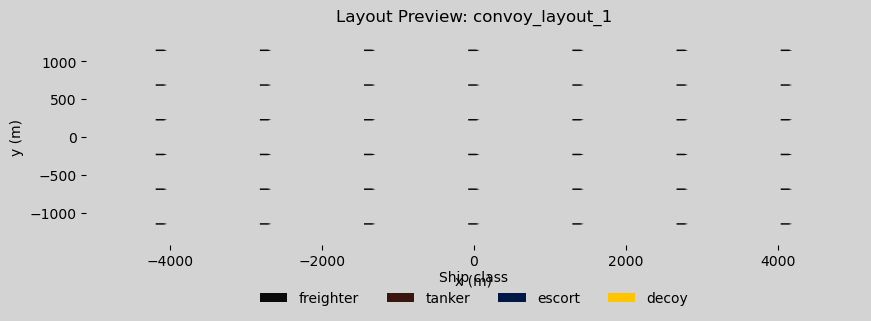

In [13]:
ships_layout_only = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
fig, ax = plt.subplots(figsize=(10, 7), facecolor='lightgrey')
plot_convoy_planview(
    ships_layout_only,
    ax=ax,
    title=f'Layout Preview: {CONVOY_PROFILE}',
    color_by='class',
    show_footprint=False,
    ship_marker='ship',
    rotate_by_heading=True,
    use_hull_dimensions=True,
    axes_facecolor='lightgrey',
)

# Add a bit of room around ships so they are not touching borders.
positions = np.array([ship.position for ship in ships_layout_only], dtype=float)
xmin, ymin = np.min(positions, axis=0)
xmax, ymax = np.max(positions, axis=0)
width = float(xmax - xmin)
height = float(ymax - ymin)
xpad = max(200.0, 0.12 * max(width, 1.0))
ypad = max(200.0, 0.12 * max(height, 1.0))
ax.set_xlim(float(xmin - xpad), float(xmax + xpad))
ax.set_ylim(float(ymin - ypad), float(ymax + ypad))

# Move legend down so it does not overlap x-axis.
leg = ax.get_legend()
if leg is not None:
    leg.set_bbox_to_anchor((0.5, -0.34))

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_aspect('equal', adjustable='box')
fig.subplots_adjust(bottom=0.26)
plt.show()


In [14]:
def _build_demo_dynamics(ships_t0, t_end_s: float):
    formation = ConvoyFormation(
        ships0=ships_t0,
        convoy_origin0=np.array([0.0, 0.0], dtype=float),
        convoy_heading0=0.0,
    )
    route = RoutePlan(legs=[RouteLeg(duration_s=max(120.0, float(t_end_s)), heading_rad=0.0)])
    zigzag = ZigZagPlan(enabled=True, amplitude_rad=0.12, period_s=60.0, phase_s=0.0, waveform='sine')
    kin = ConvoyKinematics(route=route, zigzag=zigzag)
    return formation, kin


def _view_bounds_for_points(points: np.ndarray) -> tuple[float, float, float, float]:
    xmin, ymin = np.min(points, axis=0)
    xmax, ymax = np.max(points, axis=0)
    width = float(xmax - xmin)
    height = float(ymax - ymin)
    xpad = max(250.0, 0.15 * max(width, 1.0))
    ypad = max(250.0, 0.15 * max(height, 1.0))
    return (float(xmin - xpad), float(xmax + xpad), float(ymin - ypad), float(ymax + ypad))


In [15]:
ships_t0 = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
dynamics = _build_demo_dynamics(ships_t0, FRAME_TIME_S)

profiles = PROFILE_LIBRARY.profiles
if SELECT_PROFILE_IDS is not None:
    selected = set(SELECT_PROFILE_IDS)
    profiles = [p for p in profiles if p.profile_id in selected]

saved = []
ship_points = np.array([ship.position for ship in ships_t0], dtype=float)

for idx, profile in enumerate(profiles):
    rng = np.random.default_rng(RNG_SEED + idx)
    torpedoes = profile.build_torpedoes(rng=rng)

    u_pos = np.asarray(profile.u_pos, dtype=float)
    points_for_bounds = np.vstack([ship_points, u_pos.reshape(1, 2)])
    view_bounds = _view_bounds_for_points(points_for_bounds)

    out_dir = OUTPUT_ROOT / profile.profile_id
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / FRAME_NAME

    fig, ax = plt.subplots(figsize=(6, 6), facecolor='lightgrey')
    viz_attack.render_attack_frame(
        ships_t0=ships_t0,
        torpedoes=torpedoes,
        t_global=float(FRAME_TIME_S),
        t_max=float(FRAME_TIME_S),
        dynamics=dynamics,
        ax=ax,
        color_by='class',
        show_trails=True,
        trail_length_s=40.0,
        show_footprint=False,
        ship_marker='ship',
        rotate_by_heading=True,
        use_hull_dimensions=True,
        trail_color='red',
        legend_bbox_to_anchor=(0.5, -0.31),
        view_bounds=view_bounds,
        hide_spines=True,
        apply_hit_slowdown=APPLY_HIT_SLOWDOWN,
        hit_slowdown=HIT_SLOWDOWN,
        figure_facecolor='lightgrey',
        show_u_boat=True,
        u_boat_position=u_pos,
        u_boat_marker='o',
        u_boat_color='black',
        u_boat_size=36.0,
        u_boat_label='U-boat',
    )
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)

    saved.append((profile.profile_id, str(out_path)))

print(f'Rendered {len(saved)} profiles to frame_0600.')
for profile_id, path in saved:
    print(profile_id, '->', path)


Rendered 25 profiles to frame_0600.
P01 -> results/frames/attack_profile_previews/P01/frame_0600.png
P02 -> results/frames/attack_profile_previews/P02/frame_0600.png
P03 -> results/frames/attack_profile_previews/P03/frame_0600.png
P04 -> results/frames/attack_profile_previews/P04/frame_0600.png
P05 -> results/frames/attack_profile_previews/P05/frame_0600.png
P06 -> results/frames/attack_profile_previews/P06/frame_0600.png
P07 -> results/frames/attack_profile_previews/P07/frame_0600.png
P08 -> results/frames/attack_profile_previews/P08/frame_0600.png
P09 -> results/frames/attack_profile_previews/P09/frame_0600.png
P10 -> results/frames/attack_profile_previews/P10/frame_0600.png
P11 -> results/frames/attack_profile_previews/P11/frame_0600.png
P12 -> results/frames/attack_profile_previews/P12/frame_0600.png
P13 -> results/frames/attack_profile_previews/P13/frame_0600.png
P14 -> results/frames/attack_profile_previews/P14/frame_0600.png
P15 -> results/frames/attack_profile_previews/P15/fram